In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Clustering
from sklearn.cluster import KMeans


### checking on our data !

In [2]:
df = pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [4]:
df.isnull().mean().sort_values(ascending=False)

company                           0.943069
agent                             0.136862
country                           0.004087
children                          0.000034
arrival_date_month                0.000000
arrival_date_week_number          0.000000
hotel                             0.000000
is_canceled                       0.000000
stays_in_weekend_nights           0.000000
arrival_date_day_of_month         0.000000
adults                            0.000000
stays_in_week_nights              0.000000
babies                            0.000000
meal                              0.000000
lead_time                         0.000000
arrival_date_year                 0.000000
distribution_channel              0.000000
market_segment                    0.000000
previous_bookings_not_canceled    0.000000
is_repeated_guest                 0.000000
reserved_room_type                0.000000
assigned_room_type                0.000000
booking_changes                   0.000000
previous_ca

In [5]:
leakage_cols = [
    "reservation_status",
    "reservation_status_date"
]

df = df.drop(columns=leakage_cols)


In [ ]:
df = df.drop(columns=["company"])              
df["agent"] = df["agent"].fillna(-1)           
df["country"] = df["country"].fillna("Unknown")
df["children"] = df["children"].fillna(0)


In [ ]:
df = df.dropna()

In [8]:
target = "is_canceled"
X = df.drop(columns=[target])
y = df[target]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### classification models !

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.8187871681045313
[[13665  1368]
 [ 2959  5886]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86     15033
           1       0.81      0.67      0.73      8845

    accuracy                           0.82     23878
   macro avg       0.82      0.79      0.80     23878
weighted avg       0.82      0.82      0.81     23878



In [14]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Accuracy: 0.859075299438814
[[13290  1743]
 [ 1622  7223]]
              precision    recall  f1-score   support

           0       0.89      0.88      0.89     15033
           1       0.81      0.82      0.81      8845

    accuracy                           0.86     23878
   macro avg       0.85      0.85      0.85     23878
weighted avg       0.86      0.86      0.86     23878



In [16]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)


In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


Accuracy: 0.8264511265600134
[[13112  1921]
 [ 2223  6622]]
              precision    recall  f1-score   support

           0       0.86      0.87      0.86     15033
           1       0.78      0.75      0.76      8845

    accuracy                           0.83     23878
   macro avg       0.82      0.81      0.81     23878
weighted avg       0.83      0.83      0.83     23878



### clustering part

In [ ]:
X_cluster = X_train_scaled

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

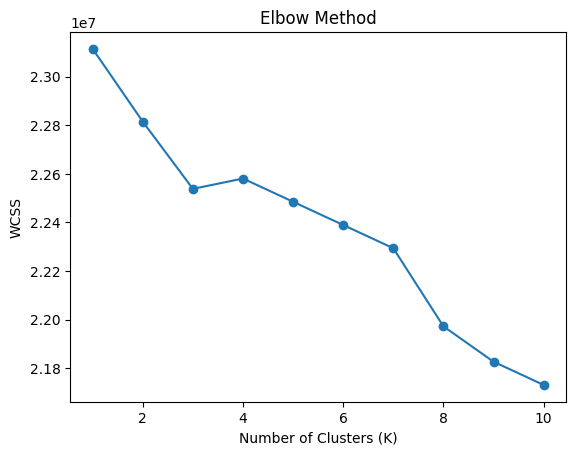

In [ ]:
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_cluster)

In [ ]:
df_clustered = df.loc[X_train.index].copy()
df_clustered["cluster"] = clusters

In [33]:
num_cols = df_clustered.select_dtypes(include=[np.number]).columns

In [32]:
df_clustered.groupby("cluster")[num_cols].mean()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,cluster
cluster,,,,,,,,,,,,,,,,,,,,
0,0.330379,83.159483,2016.286087,26.445135,15.795138,1.061245,2.725366,1.968131,0.154656,0.008526,0.009120,0.011335,0.017527,0.196257,85.958062,0.002888,113.750814,0.065459,0.850132,0.0
1,0.543293,171.080242,2015.938758,28.690954,15.769793,0.800748,2.315157,1.763549,0.005844,0.001436,0.014158,0.215447,0.016329,0.186630,68.309413,7.327111,83.911191,0.010652,0.136241,1.0
2,0.160384,39.606034,2016.154389,26.309644,15.873918,0.729652,2.103237,1.662915,0.124617,0.017650,0.141801,0.073931,0.785067,0.372785,49.378447,0.071800,97.114196,0.154589,0.498601,2.0


In [34]:
df_clustered["cluster"].value_counts()

cluster
0    50551
1    29947
2    15014
Name: count, dtype: int64

In [ ]:
df_clustered.groupby("cluster")["hotel"].value_counts().head(10)

cluster  hotel       
0        City Hotel      33482
         Resort Hotel    17069
1        City Hotel      22557
         Resort Hotel     7390
2        City Hotel       7546
         Resort Hotel     7468
Name: count, dtype: int64

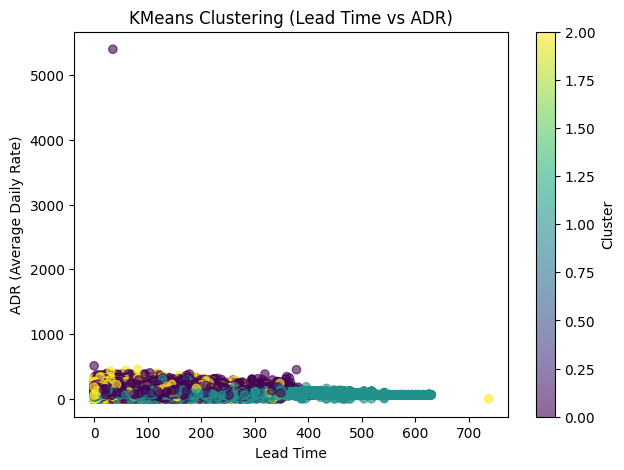

In [27]:
plt.figure(figsize=(7,5))
plt.scatter(
    df_clustered["lead_time"],
    df_clustered["adr"],
    c=df_clustered["cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Lead Time")
plt.ylabel("ADR (Average Daily Rate)")
plt.title("KMeans Clustering (Lead Time vs ADR)")
plt.colorbar(label="Cluster")
plt.show()


In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)


In [29]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = clusters


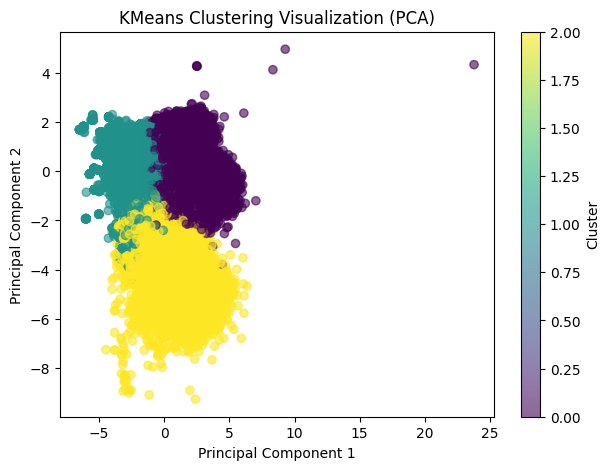

In [30]:
plt.figure(figsize=(7,5))
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clustering Visualization (PCA)")
plt.colorbar(label="Cluster")
plt.show()


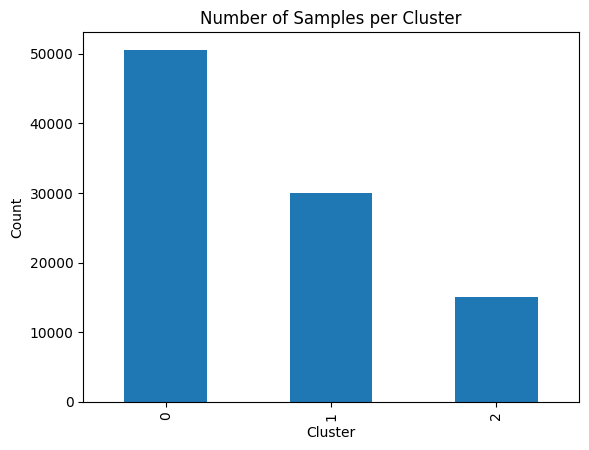

In [31]:
df_clustered["cluster"].value_counts().plot(
    kind="bar",
    title="Number of Samples per Cluster"
)
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()
